In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [4]:
# Paths
MODEl_PATH = "../models/xgb_fraud_model.pkl"
DATA_PATH = "../data/processed_data/"
VISUALS_DIR = "../visuals/shap/"

os.makedirs(VISUALS_DIR, exist_ok=True)

In [5]:
# Load the trained model
model = joblib.load(MODEl_PATH)

# Load the processed data
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy"))
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))

print('Model and data loaded successfully.')

Model and data loaded successfully.


In [6]:
# SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print('SHAP values calculated successfully.')

SHAP values calculated successfully.


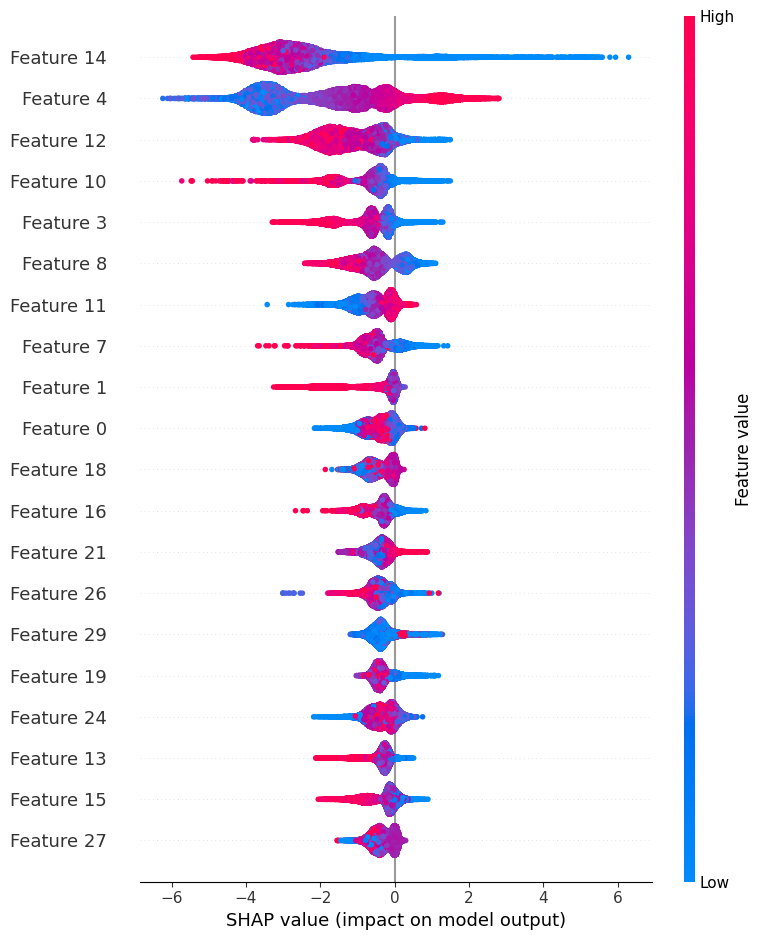

In [ ]:
# Global Feature Importance (SHAP Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig(os.path.join(VISUALS_DIR, "shap_summary_plot.png"), bbox_inches='tight')
plt.show() 

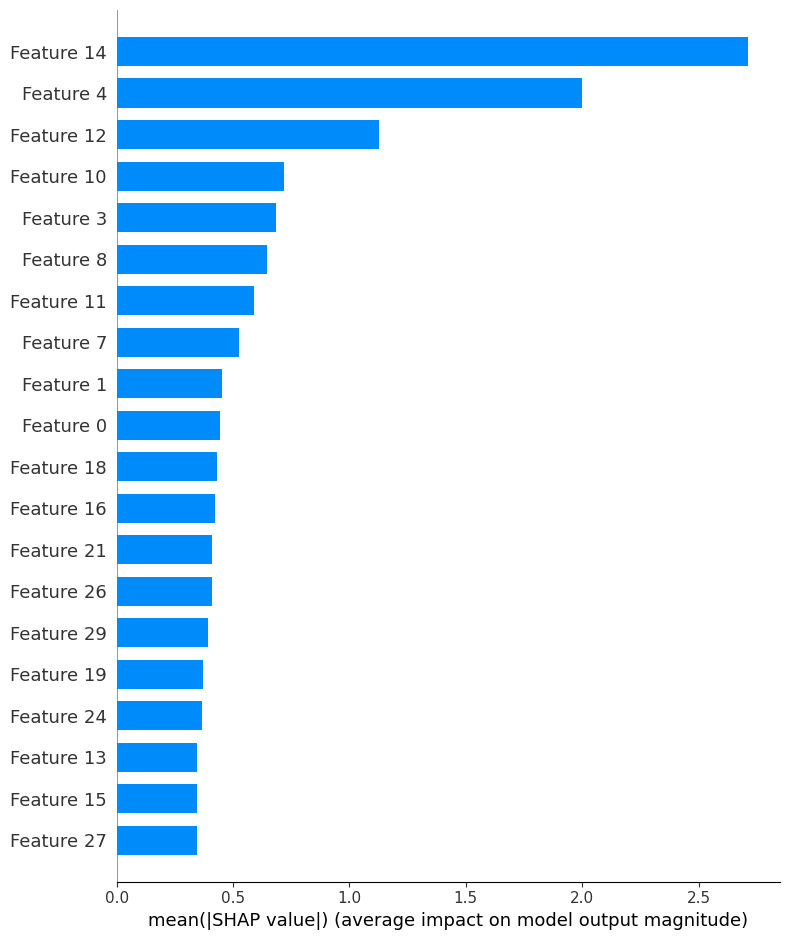

In [8]:
# Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig(os.path.join(VISUALS_DIR, "shap_bar_plot.png"), bbox_inches='tight')
plt.show()

In [9]:
# Find indices of fraudulent transactions in test set
fraud_indices = np.where(y_test == 1)[0]

# Pick first fraud transaction
fraud_idx = fraud_indices[0]

print(f"Explaining fraud transaction at index: {fraud_idx}")

Explaining fraud transaction at index: 840


In [11]:
# SHAP Local Explanation (Force Plot)
force_plot = shap.force_plot(explainer.expected_value, shap_values[fraud_idx], X_test[fraud_idx])
shap.save_html(os.path.join(VISUALS_DIR, "shap_force_plt_fraud_txn.html"), force_plot)
force_plot

In [12]:
# Save SHAP values
np.save(os.path.join(VISUALS_DIR, "shap_values.npy"), shap_values)
print("SHAP values saved for LLM explaination layer")

SHAP values saved for LLM explaination layer
